In [2]:
# LightGBM kurulu değilse kur
import subprocess
subprocess.run(['pip', 'install', 'lightgbm'], check=True)

CompletedProcess(args=['pip', 'install', 'lightgbm'], returncode=0)

In [3]:
import sys
sys.path.append('../../')

import logging
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s | %(name)s | %(levelname)s | %(message)s'
)

from src.io.save_artifacts import load_parquet, save_parquet, create_dirs
from src.features.feature_selection import FeatureSelector

df = load_parquet(
    '../../data/processed/lending_club_features_final.parquet')
print(f"Yüklenen shape: {df.shape}")

📂 Parquet okunuyor: ../../data/processed/lending_club_features_final.parquet
✅ Okundu!
   Satır : 1,345,350
   Sütun : 150
   Süre  : 0.4 saniye
Yüklenen shape: (1345350, 150)


In [4]:
print("── Yıl Dağılımı ")
yil_dagilim = df['issue_d_YIL'].value_counts().sort_index()
print(yil_dagilim.to_string())
print()

df_train = df[df['issue_d_YIL'] <= 2016].copy()
df_val   = df[df['issue_d_YIL'] == 2017].copy()
df_test  = df[df['issue_d_YIL'] == 2018].copy()

print(f"── Split Sonuçları ")
print(f"   Train (2007-2016): {len(df_train):>10,} satır "
      f"| default: %{df_train['target'].mean()*100:.1f}")
print(f"   Val   (2017)     : {len(df_val):>10,} satır "
      f"| default: %{df_val['target'].mean()*100:.1f}")
print(f"   Test  (2018)     : {len(df_test):>10,} satır "
      f"| default: %{df_test['target'].mean()*100:.1f}")

── Yıl Dağılımı 
issue_d_YIL
2007.0       251
2008.0      1562
2009.0      4716
2010.0     11536
2011.0     21721
2012.0     53367
2013.0    134804
2014.0    223103
2015.0    375546
2016.0    293105
2017.0    169321
2018.0     56318

── Split Sonuçları 
   Train (2007-2016):  1,119,711 satır | default: %19.7
   Val   (2017)     :    169,321 satır | default: %23.1
   Test  (2018)     :     56,318 satır | default: %15.8


📁 Klasör hazır: ../../reports/eda_plots


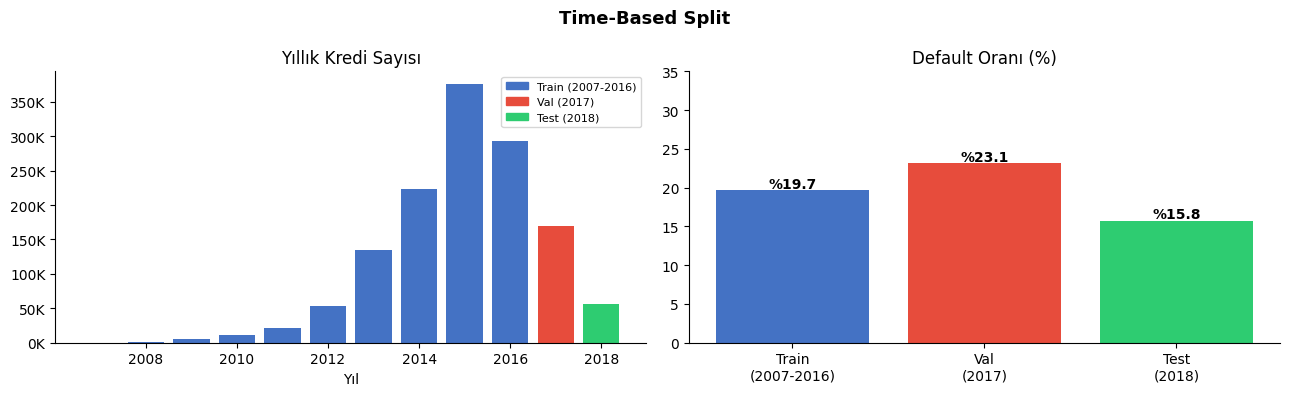

✅ 10_split_dagilim.png kaydedildi


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Time-Based Split', fontsize=13, fontweight='bold')

renk_map = {
    y: '#4472C4' if y <= 2016
    else '#E74C3C' if y == 2017
    else '#2ECC71'
    for y in yil_dagilim.index
}
axes[0].bar(yil_dagilim.index, yil_dagilim.values,
            color=[renk_map[y] for y in yil_dagilim.index],
            edgecolor='none')
axes[0].set_title('Yıllık Kredi Sayısı')
axes[0].set_xlabel('Yıl')
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

from matplotlib.patches import Patch
axes[0].legend(handles=[
    Patch(color='#4472C4', label='Train (2007-2016)'),
    Patch(color='#E74C3C', label='Val (2017)'),
    Patch(color='#2ECC71', label='Test (2018)')
], fontsize=8)

splits  = ['Train\n(2007-2016)', 'Val\n(2017)', 'Test\n(2018)']
oranlar = [df_train['target'].mean() * 100,
           df_val['target'].mean()   * 100,
           df_test['target'].mean()  * 100]
bars = axes[1].bar(splits, oranlar,
                   color=['#4472C4','#E74C3C','#2ECC71'],
                   edgecolor='none')
axes[1].set_title('Default Oranı (%)')
axes[1].set_ylim(0, 35)
for bar, v in zip(bars, oranlar):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 v + 0.3, f'%{v:.1f}',
                 ha='center', fontsize=10, fontweight='bold')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
create_dirs('../../reports/eda_plots')
plt.savefig('../../reports/eda_plots/10_split_dagilim.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ 10_split_dagilim.png kaydedildi')

In [6]:
selector = FeatureSelector(
    target_col        = 'target',
    exclude_cols      = ['issue_d_YIL', 'row_id'],  
    missing_thresh    = 0.95,
    variance_thresh   = 0.01,
    corr_thresh       = 0.95,
    iv_thresh         = 0.02,
    iv_bins           = 10,
    iv_max_categories = 50,
    lgbm_percentile   = 0.25,
    lgbm_n_est        = 200,
    perm_thresh       = 0.0005,
    perm_n_repeats    = 5,
    perm_sample_size  = 50_000
)

print("⏳ fit() başlıyor — sadece train üzerinde çalışılıyor...")
print("   Tahmini süre: 5-15 dakika (LightGBM + Permutation)")
print()

selector.fit(df_train)
selector.summary()

2026-03-05 12:54:06,839 | src.features.feature_selection | INFO | FeatureSelector.fit() başladı — 147 aday kolon
2026-03-05 12:54:07,014 | src.features.feature_selection | INFO | Adım 1 Missing     :   0 elendi → 147 kaldı


⏳ fit() başlıyor — sadece train üzerinde çalışılıyor...
   Tahmini süre: 5-15 dakika (LightGBM + Permutation)



2026-03-05 12:54:08,468 | src.features.feature_selection | INFO | Adım 2 Variance    :  21 elendi → 126 kaldı
2026-03-05 12:54:43,650 | src.features.feature_selection | INFO | Adım 3 Korelasyon  :  19 elendi → 107 kaldı
2026-03-05 12:54:53,458 | src.features.feature_selection | INFO | Adım 4 IV          :  62 elendi → 45 kaldı
2026-03-05 12:55:08,705 | src.features.feature_selection | INFO | LGBM — sıfır: 12 | alt %25: 9 | n_est: 200
2026-03-05 12:55:08,720 | src.features.feature_selection | INFO | Adım 5 LightGBM    :  21 elendi → 24 kaldı
2026-03-05 12:55:27,925 | src.features.feature_selection | INFO | Permutation — eşik: 0.0005 | elenen: 0 | sample: 50000 (stratified)
2026-03-05 12:55:27,948 | src.features.feature_selection | INFO | Adım 6 Permutation :   0 elendi → 24 kaldı
2026-03-05 12:55:27,950 | src.features.feature_selection | INFO | FeatureSelector.fit() tamamlandı — final: 24 feature


── Feature Selection Özeti ──────────────────
   Başlangıç            :  147 feature
   Adım 1 Missing       :    0 elendi
   Adım 2 Variance      :   21 elendi
   Adım 3 Korelasyon    :   19 elendi
   Adım 4 IV            :   62 elendi
   Adım 5 LightGBM      :   21 elendi
   Adım 6 Permutation   :    0 elendi
   ─────────────────────────────────────────
   Final feature sayısı :   24


'── Feature Selection Özeti ──────────────────\n   Başlangıç            :  147 feature\n   Adım 1 Missing       :    0 elendi\n   Adım 2 Variance      :   21 elendi\n   Adım 3 Korelasyon    :   19 elendi\n   Adım 4 IV            :   62 elendi\n   Adım 5 LightGBM      :   21 elendi\n   Adım 6 Permutation   :    0 elendi\n   ─────────────────────────────────────────\n   Final feature sayısı :   24'

In [7]:
# Seçilen 25 feature'ı gör
print("── Seçilen 25 Feature ───────────────────────")
for i, f in enumerate(selector.selected_features, 1):
    iv_row = selector.reports['iv'][
        selector.reports['iv']['kolon'] == f
    ]
    iv_val = iv_row['iv'].values[0] \
             if len(iv_row) > 0 else None
    print(f"   {i:2d}. {f:<40} IV={iv_val:.4f}"
          if iv_val else f"   {i:2d}. {f}")

── Seçilen 25 Feature ───────────────────────
    1. loan_amnt                                IV=0.0320
    2. grade                                    IV=0.4067
    3. annual_inc                               IV=0.0303
    4. dti                                      IV=0.0768
    5. fico_range_low                           IV=0.1230
    6. total_rev_hi_lim                         IV=0.0261
    7. acc_open_past_24mths                     IV=0.0809
    8. avg_cur_bal                              IV=0.0448
    9. bc_util                                  IV=0.0246
   10. mo_sin_old_rev_tl_op                     IV=0.0244
   11. mort_acc                                 IV=0.0265
   12. mths_since_recent_bc                     IV=0.0283
   13. num_actv_rev_tl                          IV=0.0306
   14. tot_hi_cred_lim                          IV=0.0389
   15. total_bc_limit                           IV=0.0383
   16. issue_d_AY_FARK                          IV=0.0342
   17. income_to_loan_rati

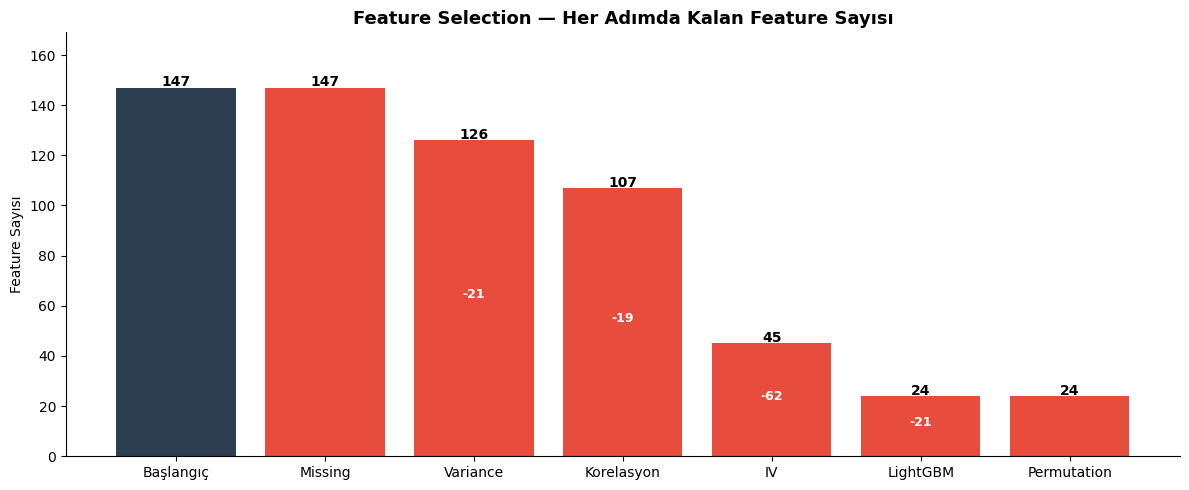

✅ 11_feature_selection_adimlar.png kaydedildi


In [8]:
dropped  = selector.dropped_features
adim_map = {
    'missing'    : 'Missing',
    'variance'   : 'Variance',
    'correlation': 'Korelasyon',
    'iv'         : 'IV',
    'lgbm'       : 'LightGBM',
    'permutation': 'Permutation'
}

baslangic = sum(len(v) for v in dropped.values()) \
            + len(selector.selected_features)

etiketler = ['Başlangıç'] + list(adim_map.values())
kalan     = [baslangic]
toplam    = baslangic

for adim in adim_map.keys():
    toplam -= len(dropped[adim])
    kalan.append(toplam)

fig, ax = plt.subplots(figsize=(12, 5))
renkler = ['#2C3E50'] + ['#E74C3C'] * 6
bars    = ax.bar(etiketler, kalan,
                 color=renkler, edgecolor='none')

for bar, v in zip(bars, kalan):
    ax.text(bar.get_x() + bar.get_width()/2,
            v + 0.5, str(v),
            ha='center', fontsize=10, fontweight='bold')

# Elenen sayısını bar altına yaz
for i, adim in enumerate(adim_map.keys(), start=1):
    n = len(dropped[adim])
    if n > 0:
        ax.text(i, kalan[i] / 2,
                f'-{n}', ha='center',
                fontsize=9, color='white', fontweight='bold')

ax.set_title('Feature Selection — Her Adımda Kalan Feature Sayısı',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Feature Sayısı')
ax.set_ylim(0, max(kalan) * 1.15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(
    '../../reports/eda_plots/11_feature_selection_adimlar.png',
    dpi=150, bbox_inches='tight')
plt.show()
print('✅ 11_feature_selection_adimlar.png kaydedildi')